# Error Type Variety in `final_dataset.json`

This notebook loads the dataset, extracts the leading error class from each `error_type` entry, summarizes the distribution, and visualizes it with a bar chart and a pie chart.

In [2]:
from pathlib import Path
import json
from collections import Counter

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT.parent / "Datasets" / "final_dataset.json"

with DATASET_PATH.open("r", encoding="utf-8") as file:
    records = json.load(file)

print(f"Loaded {len(records):,} records from {DATASET_PATH}")
if records:
    print("Keys in the first record:", sorted(records[0].keys()))

Loaded 582 records from c:\Users\hbahmanyar\MentorApp\Datasets\final_dataset.json
Keys in the first record: ['correct_code', 'description', 'difficulty', 'error_type', 'incorrect_code', 'title']


In [3]:
def extract_error_class(error_value):
    if not isinstance(error_value, str) or not error_value.strip():
        return "Missing"

    primary_message = error_value.split("||", 1)[0].strip()
    error_class = primary_message.split(":", 1)[0].strip()
    return error_class or "Unlabeled"

error_counts = Counter(extract_error_class(item.get("error_type")) for item in records)
sorted_counts = sorted(error_counts.items(), key=lambda pair: (-pair[1], pair[0]))

print(f"Unique error classes: {len(sorted_counts)}")
print()
for error_name, count in sorted_counts:
    print(f"{error_name:<20} {count}")

Unique error classes: 9

NameError            116
ValueError           95
SyntaxError          74
LogicError           68
IndexError           59
AttributeError       56
KeyError             56
TypeError            34
ImportError          24


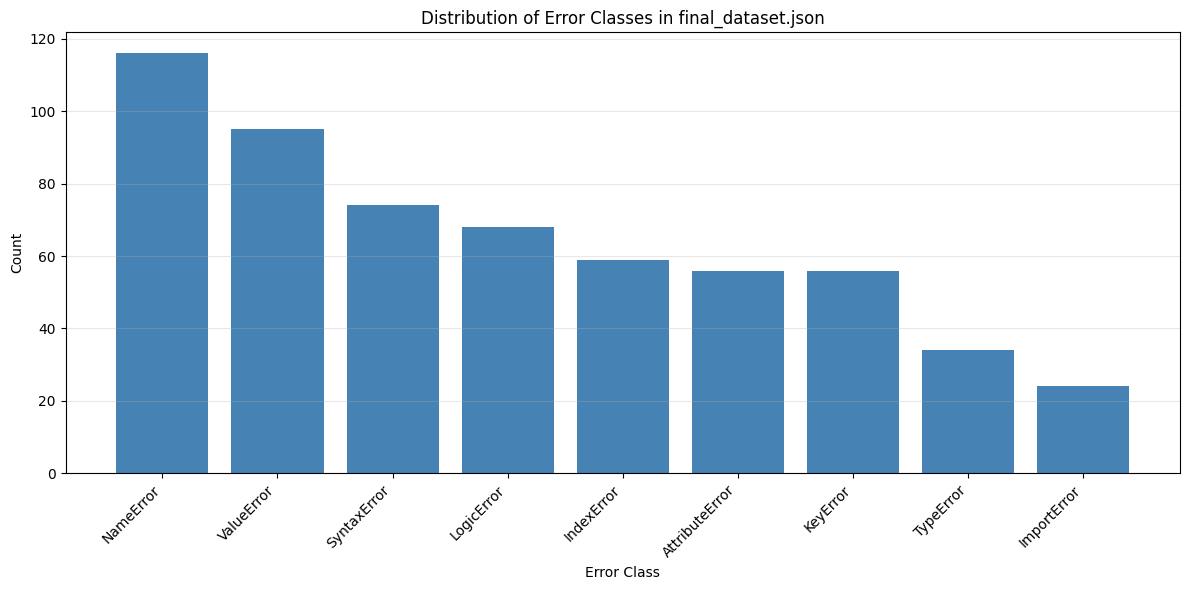

In [4]:
labels = [name for name, _ in sorted_counts]
values = [count for _, count in sorted_counts]

plt.figure(figsize=(12, 6))
plt.bar(labels, values, color="steelblue")
plt.title("Distribution of Error Classes in final_dataset.json")
plt.xlabel("Error Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

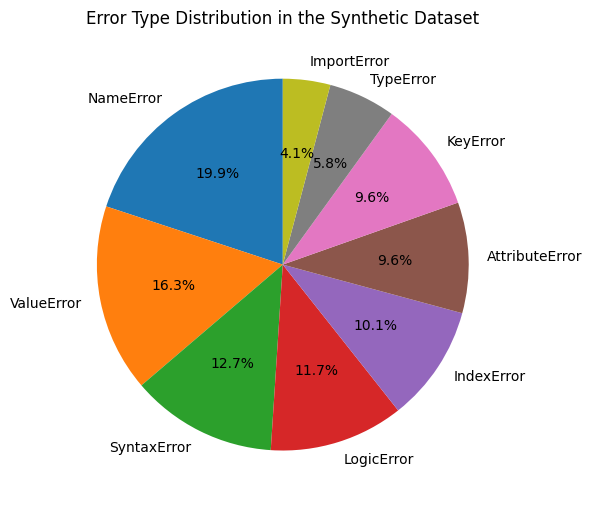

In [5]:
top_n = 10
top_counts = sorted_counts[:top_n]
other_count = sum(count for _, count in sorted_counts[top_n:])

pie_labels = [name for name, _ in top_counts]
pie_values = [count for _, count in top_counts]

if other_count:
    pie_labels.append("Other")
    pie_values.append(other_count)

plt.figure(figsize=(6, 6))
plt.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90)
plt.title("Error Type Distribution in the Synthetic Dataset")
plt.tight_layout()
plt.show()